# Ploting the RTP Log files

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axisartist.parasite_axes import HostAxes
import re
import os

import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True                    # render text via LaTeX
})

In [3]:
file_path = r"..\Data\RTP\2Box_750C_20s_900C_120s_N2_2Vac_noRot.csv"
# file_path = r"C:\Users\lhager\Downloads\rtp-logfile-viewer-main\rtp-logfile-viewer-main\Process_9472_N2high_1000°C_2min.csv"

data = pd.read_csv(file_path, delimiter=';', decimal=',', low_memory=False)
print(data.columns)

data.columns = (
    data.columns
      .str.replace(r'\[\d+\]\s*', '', regex=True)   # remove [number]
      .str.replace(r'\s+in\s+.*', '', regex=True)   # remove "in unit"
      .str.strip()                                  # remove leading/trailing spaces
)
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

# timestamp_col = "Timestamp"
for col in data.columns:
    # if col != timestamp_col:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.fillna(method="ffill")

# unit conversions
data['O2 Level'] = data['O2 Level'] * 1e6
data['Chamber_Pressure_Readout'] = data['Chamber_Pressure_Readout'] * 1.33322368421083 
print(data.info())

name = os.path.basename(file_path)

Index(['Timestamp in s', 'Recipe-Step', '[20] Ar_20slm_Readout in slm',
       '[111] Butterfly Opening in %0', '[2] Chamber_Pressure_Readout in Torr',
       '[102] HeatValue in %', '[83] N2_150slm_Readout in slm',
       '[22] N2_30slm_Readout in slm', '[84] O2 Level in pu',
       '[24] O2_20slm_Readout in slm', '[109] T_Mdl3 in °C',
       '[12] Wafer_Z_Position_Readout in mm', 'Unnamed: 12'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242304 entries, 0 to 242303
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Timestamp                 242304 non-null  float64
 1   Recipe-Step               0 non-null       float64
 2   Ar_20slm_Readout          242240 non-null  float64
 3   Butterfly Opening         242280 non-null  float64
 4   Chamber_Pressure_Readout  242304 non-null  float64
 5   HeatValue                 242302 non-null  float64
 6   N2_150slm_Rea

C:\Users\lhager\AppData\Local\Temp\ipykernel_13828\3360175374.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="ffill")


In [9]:
def plot_RTP_data(data, name):
    # colors = plt.get_cmap('viridis', 4)
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 0.80, 5))

    fig, ax1 = plt.subplots(figsize=(12,6))

    ax1.set_xlim([0, 1200])
    ax1.set_xlabel('Time / s')
    p1, = ax1.plot(data['Timestamp'], data['T_Mdl3'], label='Temperature', color=colors[0])
    ax1.set_ylabel('Temperature / °C', color=p1.get_color())
    ax1.tick_params(axis='y', which='both', colors=p1.get_color())
    ax1.spines['right'].set_color(p1.get_color())


    ax2 = ax1.twinx()
    ax2.yaxis.set_ticks_position('right')
    ax2.yaxis.set_label_position('right')
    p2, = ax2.plot(data['Timestamp'], data["Chamber_Pressure_Readout"], label='Preasure', color=colors[1])
    ax2.set_ylabel('Preasure / mbar', color=p2.get_color())
    ax2.tick_params(axis='y', which='both', colors=p2.get_color())
    ax2.spines['right'].set_color(p2.get_color())


    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 50))
    ax3.yaxis.set_ticks_position('right')
    ax3.yaxis.set_label_position('right')
    ax3.set_yscale('log')
    p3, = ax3.plot(data['Timestamp'], data['O2 Level'], label='$O_2$ Level', color=colors[2])
    ax3.set_ylabel('$O_2$ Level / ppm', color=p3.get_color())
    ax3.tick_params(axis='y', which='both', colors=p3.get_color())
    ax3.spines['right'].set_color(p3.get_color())


    ax4 = ax1.twinx()
    ax4.spines['right'].set_position(('outward', 100))
    ax4.yaxis.set_ticks_position('right')
    ax4.yaxis.set_label_position('right')
    p4, = ax4.plot(data['Timestamp'], data['N2_30slm_Readout']+ data['N2_150slm_Readout'], label='$N_2$ Flow', color=colors[3])
    # p5, = ax4.plot(data['Timestamp'], data['N2_150slm_Readout'], label='$N_2$ Flow 150', color=colors(5))
    ax4.set_ylabel('$N_2$ Flow / slm', color=p4.get_color())
    ax4.tick_params(axis='y', which='both', colors=p4.get_color())
    ax4.spines['right'].set_color(p4.get_color())

    ax5 = ax1.twinx()
    ax5.spines['left'].set_position(('outward', 50))
    ax5.yaxis.set_ticks_position('left')
    ax5.yaxis.set_label_position('left')
    p5, = ax5.plot(data['Timestamp'], data["HeatValue"], label='HeatValue', color=colors[4])
    ax5.set_ylabel('HeatValue / %', color=p5.get_color())
    ax5.tick_params(axis='y', which='both', colors=p5.get_color())
    ax5.spines['left'].set_color(p5.get_color())


    lines = [p1, p2, p3, p4, p5]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    plt.tight_layout()
    plt.grid(True)
    # plt.savefig(f'../Images/RTP/{name}.pdf', dpi=500)
    plt.show()

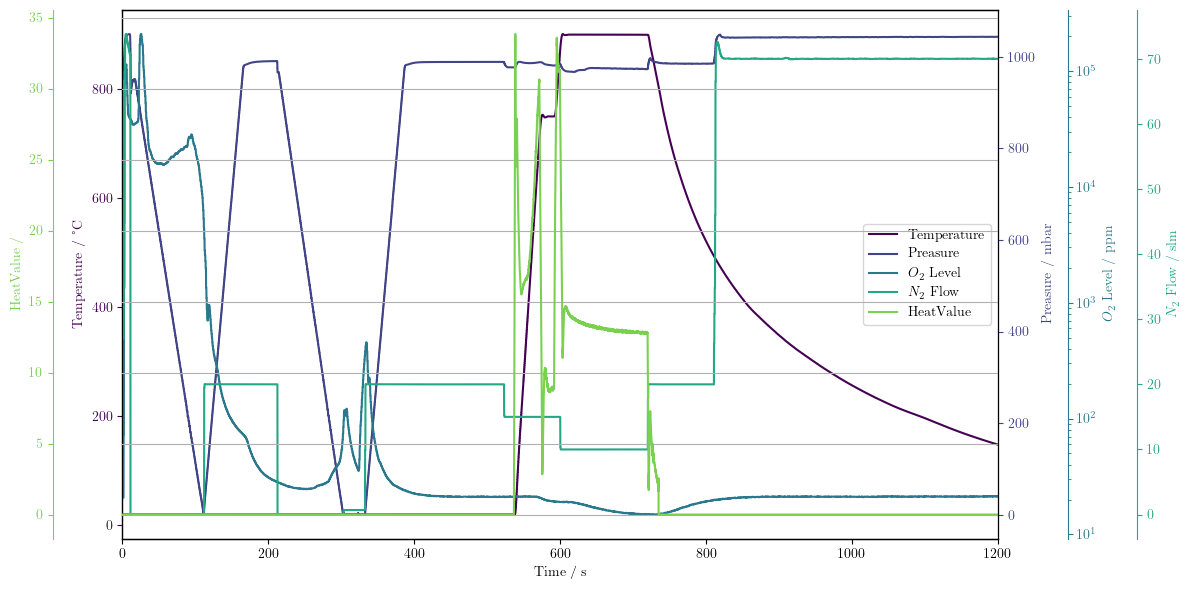

In [10]:
plot_RTP_data(data=data, name=name)

In [11]:
# fig = make_subplots(specs=[[{"secondary_y": True}]])

# # 1. Plot the Experimental Data (the black line)
# fig.add_trace(go.Scatter(x=data['Timestamp'], y=data['T_Mdl3'], 
#                         mode='lines', name='Temperature / °C', line=dict(color='red', width=1.5)),
#             secondary_y=False)

# fig.add_trace(go.Scatter(x=data['Timestamp'], y=data['O2 Level'], 
#                         mode='lines', name='O_2 Level / ppm', line=dict(color='black', width=1.5)),
#             secondary_y=True)

# fig.update_xaxes(title_text="Time / s")
# # Set y-axes titles
# fig.update_yaxes(title_text="Temperature / °C", secondary_y=False)
# fig.update_yaxes(title_text="O_2 Level / ppm", secondary_y=True, type="log")

# fig.show()

# # fig.write_html(f'../Images/RTP/{name}.html')